In [5]:

factory_mapping = pd.DataFrame({
    "Product Name": [
        "Wonka Bar - Nutty Crunch Surprise",
        "Wonka Bar - Fudge Mallows",
        "Wonka Bar -Scrumdiddlyumptious",
        "Wonka Bar - Milk Chocolate",
        "Wonka Bar - Triple Dazzle Caramel",
        "Laffy Taffy",
        "SweeTARTS",
        "Nerds",
        "Fun Dip",
        "Fizzy Lifting Drinks",
        "Everlasting Gobstopper",
        "Hair Toffee",
        "Lickable Wallpaper",
        "Wonka Gum",
        "Kazookles"
    ],

    "Factory": [
        "Lot's O' Nuts",
        "Lot's O' Nuts",
        "Lot's O' Nuts",
        "Wicked Choccy's",
        "Wicked Choccy's",
        "Sugar Shack",
        "Sugar Shack",
        "Sugar Shack",
        "Sugar Shack",
        "Sugar Shack",
        "Secret Factory",
        "The Other Factory",
        "Secret Factory",
        "Secret Factory",
        "The Other Factory"
    ]
})

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import os

print(os.getcwd())

c:\Users\klarikach\OneDrive\Documents\Nassau_Candy_Project\notebooks


In [9]:
df = pd.read_csv("cleaned_nassau_candy_distributor.csv")

In [10]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Cost,Year,Month,Quarter,Gross Margin %,Profit Per Unit,Sales Per Unit,Cost Per Unit,Revenue Contribution %,Profit Contribution %
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,2.28,2024,January,1,64.923077,2.11,3.25,1.14,0.004584,0.004516
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,2.60,2024,January,1,65.333333,2.45,3.75,1.30,0.005290,0.005244
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3.00,2024,January,1,71.346705,2.49,3.49,1.00,0.007384,0.007994
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3.30,2024,January,1,69.444444,2.50,3.60,1.10,0.007617,0.008026
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,3.90,2024,January,1,65.333333,2.45,3.75,1.30,0.007935,0.007866


In [11]:
df_factory = pd.merge(
    df,
    factory_mapping,
    on="Product Name",
    how="left"
)

df_factory.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Year,Month,Quarter,Gross Margin %,Profit Per Unit,Sales Per Unit,Cost Per Unit,Revenue Contribution %,Profit Contribution %,Factory
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,2024,January,1,64.923077,2.11,3.25,1.14,0.004584,0.004516,Wicked Choccy's
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,2024,January,1,65.333333,2.45,3.75,1.30,0.005290,0.005244,Wicked Choccy's
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,2024,January,1,71.346705,2.49,3.49,1.00,0.007384,0.007994,Lot's O' Nuts
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,2024,January,1,69.444444,2.50,3.60,1.10,0.007617,0.008026,Lot's O' Nuts
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,2024,January,1,65.333333,2.45,3.75,1.30,0.007935,0.007866,Wicked Choccy's


In [13]:
factory_summary = df_factory.groupby("Factory").agg({
    "Sales":"sum",
    "Gross Profit":"sum",       
    "Cost":"sum",
    "Units":"sum"
}).reset_index()

factory_summary["Gross Margin %"] = (factory_summary["Gross Profit"] / factory_summary["Sales"]) * 100  



Profit by Factory

In [ ]:
factory_summary.sort_values(
    "Gross Profit",
    ascending=False
).plot(
    x="Factory",
    y="Gross Profit",
    kind="bar",
    figsize=(10, 5)
)

plt.title("Gross Profit by Factory")
plt.show()

Revenue by Factory

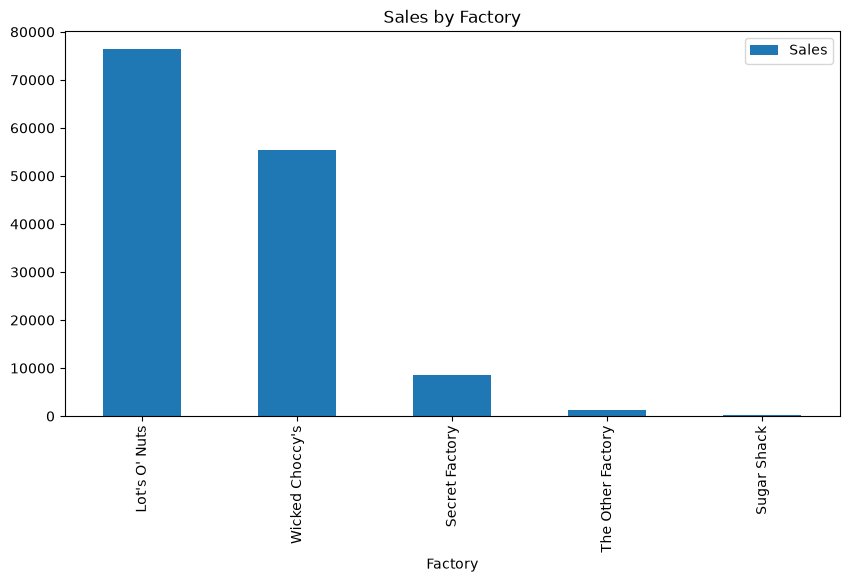

In [14]:
factory_summary.sort_values(
    "Sales",
    ascending=False
).plot(
    x="Factory",
    y="Sales",
    kind="bar",
    figsize=(10,5)
)

plt.title("Sales by Factory")
plt.show()

Margin by Factory

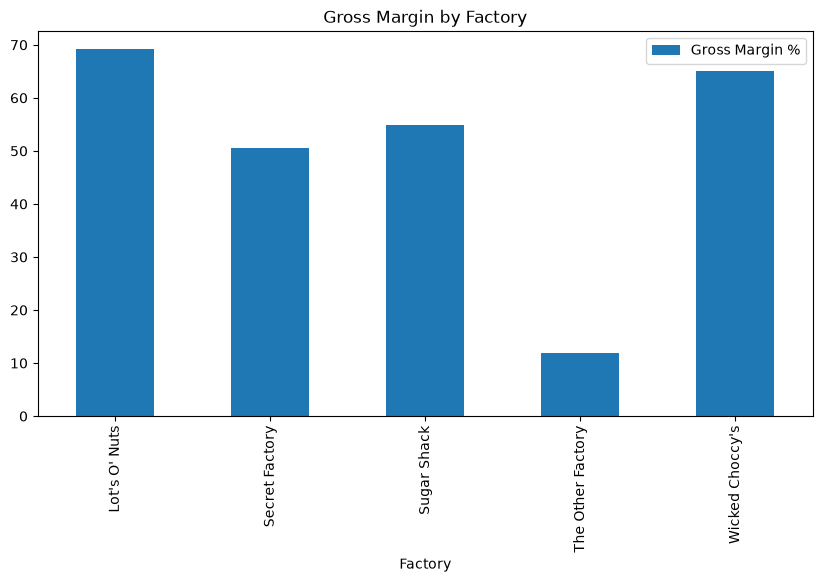

In [15]:
factory_summary.plot(
    x="Factory",
    y="Gross Margin %",
    kind="bar",
    figsize=(10,5)
)

plt.title("Gross Margin by Factory")
plt.show()

In [16]:
factory_summary

,Factory,Sales,Gross Profit,Cost,Units,Gross Margin %
0,Lot's O' Nuts,76340.15,52771.05,23569.10,21412,69.126207
1,Secret Factory,8587.50,4344.70,4242.80,884,50.593304
2,Sugar Shack,220.98,121.23,99.75,107,54.860168
3,The Other Factory,1282.25,152.25,1130.00,388,11.873660
4,Wicked Choccy's,55352.75,36053.57,19299.18,15863,65.134198
